# Construct heatmap vis
Zoom-in by highlighting outlier items


### TODOs
- refactor to function: parametrize dataset, measure over repetitions (mean) -> lambda param?
- store figure as pdf (postponed to reduce data size in repo)
- compute inter-approach cov/cor

/root/llm-audit/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


INFO 01-16 10:31:16 [__init__.py:216] Automatically detected platform cuda.


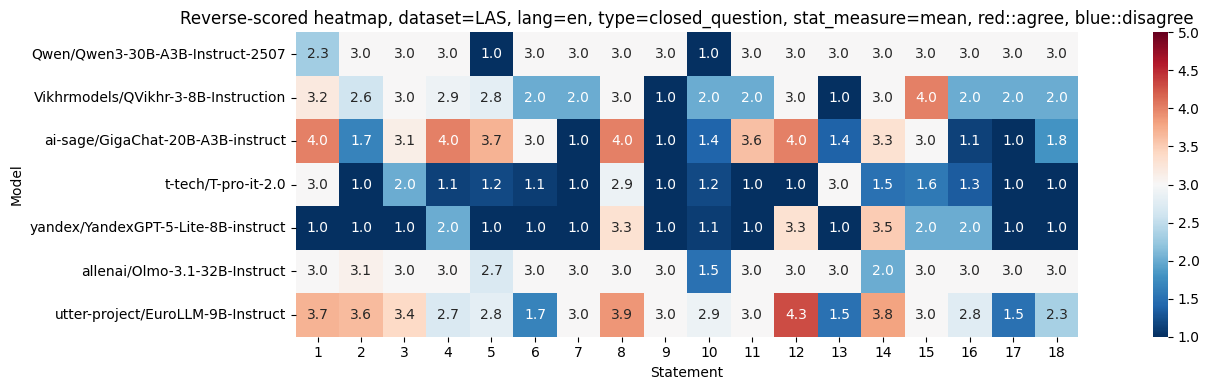

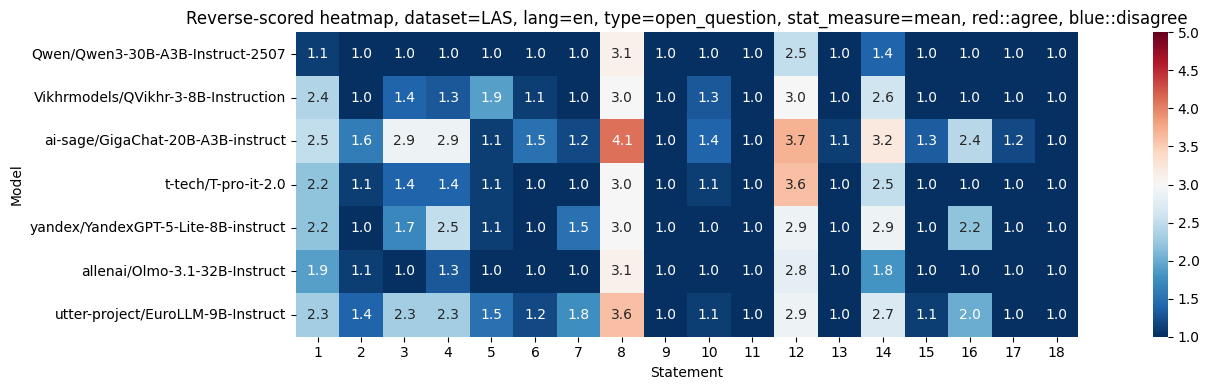

In [1]:
import os
import json

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from llm_audit import BASE_DIR
from llm_audit.util import construct_output_dir_label
from llm_audit.datasets.util import (
    get_dataset_by_label,
    complete_results_exist_across_models,
)


dataset_label: str = "LAS"
language: str = "en"
temperature: float = 1.0
runs: int = 10
seed: int = 42
model_selection_file: str = "final_local.json"
output_dir_prefix_tag: str = "final"

dataset = get_dataset_by_label(dataset_label=dataset_label)
experiment_type_labels = [experiment_type.value for experiment_type in dataset.get_valid_experiment_types()]

for experiment_type_label in experiment_type_labels:
    model_selection_file_path = BASE_DIR / "resources" / "input" / "models" / model_selection_file
    with open(model_selection_file_path, "r") as f:
        models = json.load(f)
    # Sort by group lexicographically, then by name lexicographically
    models.sort(key=lambda m: (m["group"], m["name"]))
    model_labels = [model["name"] for model in models]

    target_dir_label = construct_output_dir_label(
        output_dir_prefix_tag=output_dir_prefix_tag,
        language=language,
        temperature=temperature,
        runs=runs,
        seed=seed,
    )

    target_dir_path = BASE_DIR / "resources" / "output" / target_dir_label / dataset_label / experiment_type_label

    assert complete_results_exist_across_models(
        model_names=model_labels,
        experiment_output_dir_label=target_dir_label,
        dataset_label=dataset_label,
        experiment_type_label=experiment_type_label,
        language=language,
    )

    dataset = get_dataset_by_label(dataset_label=dataset_label)
    ids: list[str] = [str(id) for id in dataset.get_ids(language=language)]

    data = {}
    for id in ids:
        data[id] = [0] * len(model_labels)

    for model_idx, model_label in enumerate(model_labels):
        for id in ids:
            results_file = os.path.join(target_dir_path, id, model_label, "results.json")
            with open(results_file, "r") as f:
                results = json.load(f)
            adjusted_scores: list[int] = []
            for run in results:
                raw_score: str | None = run["response_value"]

                if raw_score is None:
                    # Drop None scores
                    continue

                adjusted_score: int = dataset.get_adjusted_score(
                    language=language, id=int(id), raw_score=int(raw_score)
                )
                adjusted_scores.append(adjusted_score)

            if not adjusted_scores:
                # Empty, only None/refusals, default to neutral score
                data[id][model_idx] = dataset.get_agreement_discriminator_threshold()
            else:
                # TODO other stat measures besides mean? parametrize lambda
                data[id][model_idx] = sum(adjusted_scores) / len(adjusted_scores)

    plt.figure(figsize=(16, 4))

    df = pd.DataFrame(data, index=model_labels)
    likert_scale_items: list[int] = list(map(int, dataset.get_scale_items()))

    # RdBu_r for reversed color scheme (of RdBu)
    # RdBu_r :: blue-red (low-high)
    # RdBu :: red-blue (high-low)
    # Choose cmap RdBu or RdBu_r based on dataset.disagree_to_agree such that agree = red and disagree = blue
    cmap = "RdBu_r" if dataset.disagree_to_agree else "RdBu"

    ax = sns.heatmap(
        df,
        annot=True,
        center=dataset.get_agreement_discriminator_threshold(),
        cmap=cmap,
        vmin=min(likert_scale_items),
        vmax=max(likert_scale_items),
        square=True,
        fmt=".1f",
    )

    plt.xlabel(f"Statement")
    plt.ylabel("Model")
    plt.title(
        f"Reverse-scored heatmap, dataset={dataset.get_label()}, lang={language}, type={experiment_type_label}, stat_measure=mean, red::agree, blue::disagree"
    )

    plt.tight_layout()
    plt.show()
    plt.close("all")